# Notebook for Evaluation of Training

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


e:\VSCodium\OML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from Trainer import *
from mesh import *
from baseline import *
from metrics import *
#from main import *
import numpy as np
import matplotlib.pyplot as plt

## Load data

In [18]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 200            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio)    
#E_* are the flattened arrays of the encoded mnist images (complex valued), 
#Y_* are the referring labels



Train:   160 samples, class counts {1: 80, 7: 80}
Test :    40 samples, class counts {1: 20, 7: 20}


## Creating training config

In [19]:
### CONFIG + MESH
cfg = TrainConfig(m_side=10, theta_enc=1, normalize_energy=True, encoding='amplitude', 
        detectors=(33,66), loss_kind='mse', learning_rate=0.3, batch_size=64,
                  init="random", max_epochs=10, patience=2, min_delta=0.01, 
                  param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)
mesh = MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N))

print(cfg)

TrainConfig(m_side=10, theta_enc=1, normalize_energy=True, encoding='amplitude', detectors=(33, 66), loss_kind='mse', learning_rate=0.3, batch_size=64, init='random', max_epochs=10, patience=2, min_delta=0.01, param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)


## Initiating trainer and running fit

In [33]:
trainer = Trainer(mesh, cfg)
history = trainer.fit(E_train, Y_train)

Epoch 10.00/10 | Loss: 0.4656: 100%|██████████| 30/30.0 [00:10<00:00,  2.96it/s]


## Presenting results of fit

In [32]:
test_loss, test_acc = trainer.evaluate(E_test, Y_test)
print(f"validation acc {history['acc'][-1]:.4f} | test acc {test_acc:.4f} | "
      f"{len(history['loss'])} epochs, {trainer.train_time:.1f}s")
print(f"inference: {trainer.inference_time(E_test)*1e3:.2f} ms/sample")

validation acc 0.8938 | test acc 0.9000 | 10 epochs, 9.7s
inference: 10.77 ms/sample


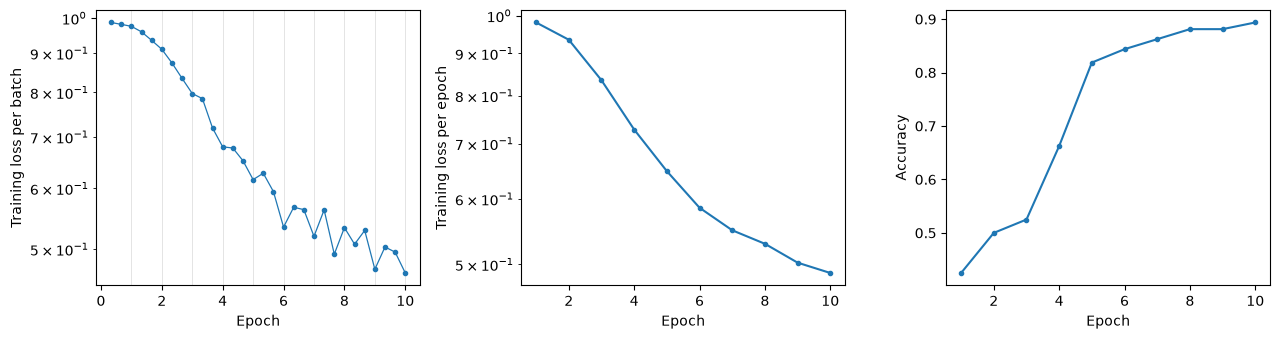

In [7]:
fig, _ = plot_training(trainer, keys=("batch_loss", "loss", "acc"))

## Saving results and reading them back

In [8]:
m="test"
trainer.save(f"results/{m}.json", test_acc=test_acc)

WindowsPath('results/test.json')

In [9]:
# laden
import os

trainer = Trainer.load(os.path.join(os.getcwd(),"results/test.json"))
print(trainer.extra["test_acc"])

0.9


## Running a sweep over an arbitrary parameter
Create a trainer instance for every sweep-position and give the whole array to "plot_training" in visualize.py

In [37]:
ms = [4, 6, 8]
trainers = []
for m in ms:
    cfg = TrainConfig(m_side=m, learning_rate=0.3, batch_size=50, param_init_seed=0, max_epochs=20)
    E_tr, y_tr, E_te, y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
    t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
    t.fit(E_tr, y_tr)
    t.test_acc = t.evaluate(E_te, y_te)[1]      
    trainers.append(t)

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 20.00/20 | Loss: 0.0476: 100%|██████████| 640/640.0 [00:04<00:00, 134.46it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 20.00/20 | Loss: 0.0196: 100%|██████████| 640/640.0 [00:21<00:00, 30.12it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 20.00/20 | Loss: 0.0071: 100%|██████████| 640/640.0 [01:17<00:00,  8.28it/s]


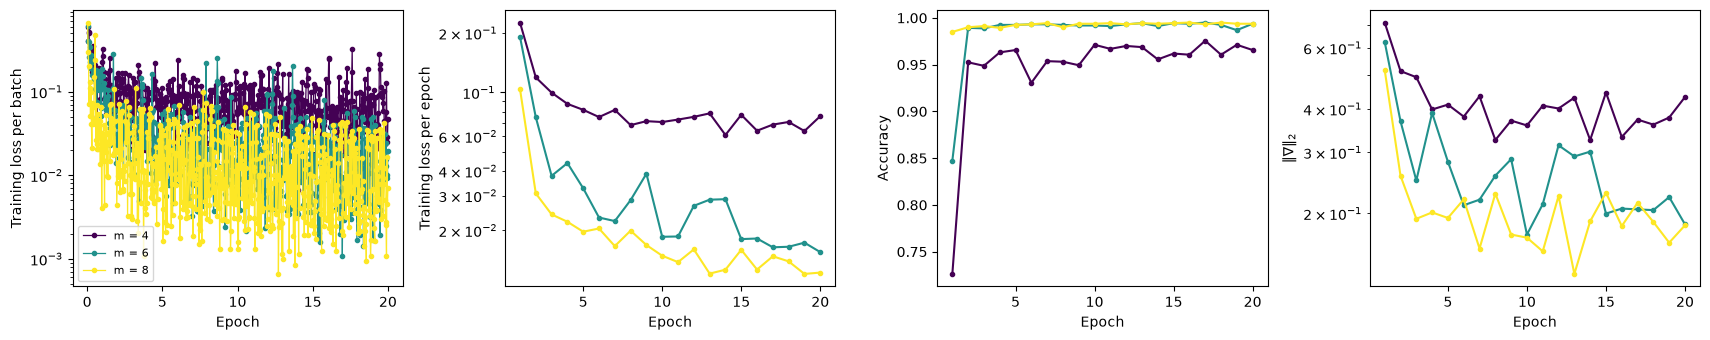

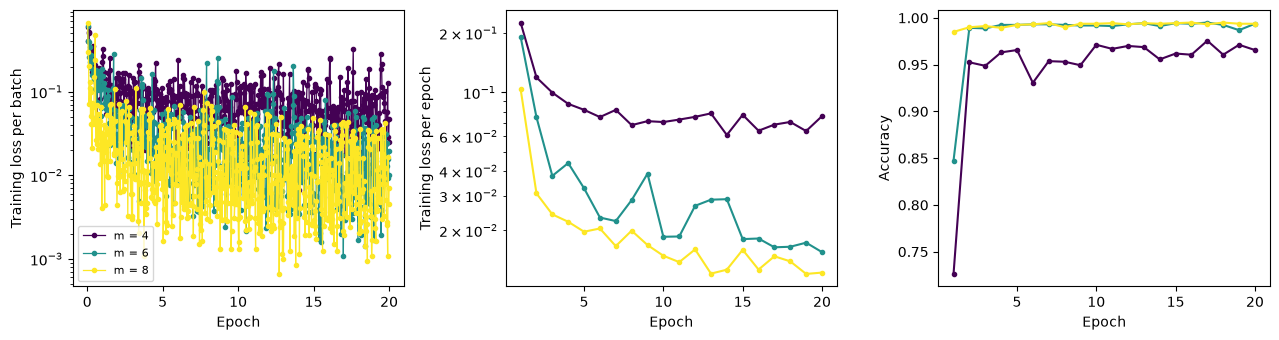

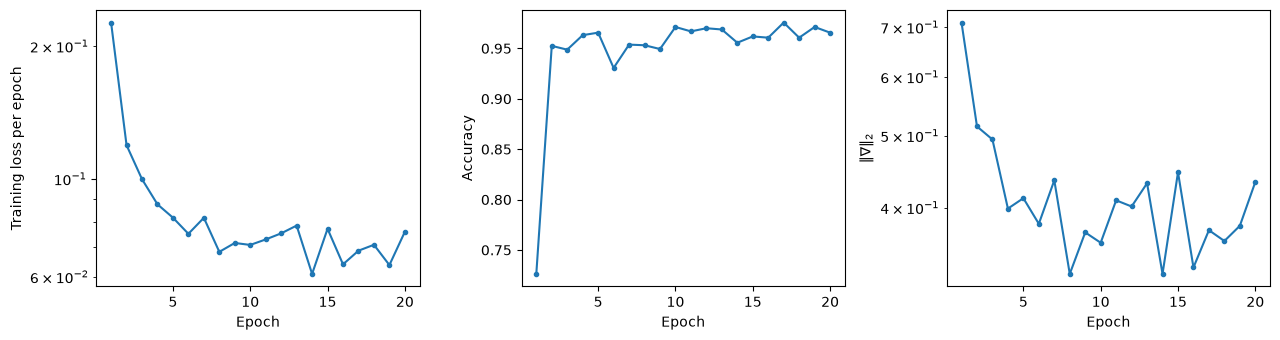

In [15]:
fig, _ = plot_training(trainers, sweep_values=ms, keys=("batch_loss", "loss", "acc", "grad_norm"))
#Von mir bevorzugter Plot
fig, _ = plot_training(trainers, sweep_values=ms, keys=("batch_loss", "loss", "acc"))

# Einzelner Lauf
fig, _ = plot_training(trainers[0])

Train:   160 samples, class counts {1: 80, 7: 80}
Test :    40 samples, class counts {1: 20, 7: 20}
Bathces per epoch:10.0


Epoch 0.10/35 | Loss: 0.9902:   0%|          | 1/350.0 [00:00<01:24,  4.13it/s]

Länge: 1, Teile durch: 10.0


Epoch 0.20/35 | Loss: 0.9931:   1%|          | 2/350.0 [00:00<01:21,  4.25it/s]

Länge: 2, Teile durch: 10.0


...

Länge: 29, Teile durch: 10.0


Epoch 3.00/35 | Loss: 0.8762:   9%|▊         | 30/350.0 [00:07<01:20,  3.99it/s]

Länge: 30, Teile durch: 10.0


Epoch 3.00/35 | Loss: 0.8762:   9%|▊         | 30/350.0 [00:07<01:24,  3.80it/s]


KeyboardInterrupt: 